# Model Development — Machine Learning-Augmented GARCH Models for VaR
**Student:** Mathonsi Mphikeleli Mbongiseni (28574249) · UNISA MCom Quantitative Management

Assets: MSFT, AAPL, NVDA, IBM, CSCO, JPM, BAC, C · Benchmarks: ^GSPC, ^IXIC · Period: Jan 2010 – Dec 2025

This notebook continues from `Exploratory Data Analysis (EDA).ipynb` and implements the dissertation's approved methodology: three GARCH-family conditional volatility models — GARCH(1,1), EGARCH(1,1) and GJR-GARCH(1,1) — are estimated as the classical econometric baseline, and a Long Short-Term Memory (LSTM) network is layered on top of their conditional variance output as an adaptive refinement step, producing a Hybrid ML-GARCH volatility forecast. Every model is backtested for VaR coverage with the Kupiec and Christoffersen tests under an identical walk-forward evaluation scheme.

## 1. Setup

In [1]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import pickle
import joblib
from pathlib import Path
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

from arch import arch_model
import keras
from keras import layers

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.6f}'.format)
np.random.seed(42)
keras.utils.set_random_seed(42)

ROOT        = Path(r'e:\Academic & Research\Msc in Quantitative Management\Research Codes')
DATA_DIR    = ROOT / 'data'
FIGURES_DIR = ROOT / 'figures'
TABLES_DIR  = ROOT / 'tables'
MODELS_DIR  = ROOT / 'models'
RESULTS_DIR = ROOT / 'results'

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

STOCKS  = ['AAPL', 'BAC', 'C', 'CSCO', 'IBM', 'JPM', 'MSFT', 'NVDA']
INDICES = ['^GSPC', '^IXIC']
NAMES   = {
    'MSFT': 'Microsoft', 'AAPL': 'Apple', 'NVDA': 'NVIDIA', 'IBM': 'IBM',
    'CSCO': 'Cisco', 'JPM': 'JPMorgan', 'BAC': 'BofA', 'C': 'Citigroup',
    '^GSPC': 'S&P 500', '^IXIC': 'NASDAQ',
}
TRADING_DAYS  = 252
CONF_LEVELS   = [0.95, 0.99]
REFIT_FREQ    = 63
TRAIN_FRAC    = 0.80
LOOKBACK      = 21
EPS           = 1e-8
PALETTE       = sns.color_palette('tab10', n_colors=10)

print('Keras backend:', keras.backend.backend())


Keras backend: torch


## 2. Data Preparation and Feature Engineering

VaR is a portfolio-level risk measure, so this notebook works with a single risk object: an equally-weighted portfolio of the eight individual equities. The two broad indices are retained as candidate diagnostic series rather than portfolio constituents, since they overlap heavily with the constituents' own systematic risk. The "feature engineering" this dissertation's architecture calls for is deliberately minimal at this stage — the GARCH layer operates directly on the portfolio's own return series, exactly as the classical econometric literature specifies; the richer engineered inputs (conditional volatility, conditional variance and standardised residuals from each GARCH variant) are constructed later, in Section 4, once the GARCH layer itself has produced them, since those quantities are what the LSTM refinement layer is designed to consume.

In [2]:
prices    = pd.read_csv(DATA_DIR / 'prices_clean.csv', index_col='Date', parse_dates=True)
ret       = pd.read_csv(DATA_DIR / 'log_returns_clean.csv', index_col='Date', parse_dates=True)
ret_wins  = pd.read_csv(DATA_DIR / 'log_returns_winsorised.csv', index_col='Date', parse_dates=True)

print(f"Prices          : {prices.shape}")
print(f"Log returns     : {ret.shape}")
print(f"Winsorised rets : {ret_wins.shape}")
print(f"Period          : {ret.index.min().date()} to {ret.index.max().date()}")


Prices          : (4023, 10)
Log returns     : (4022, 10)
Winsorised rets : (4022, 10)
Period          : 2010-01-05 to 2025-12-30


In [3]:
recomputed = np.log(prices / prices.shift(1)).dropna()
aligned    = recomputed.reindex(ret.index)
max_diff   = (aligned - ret).abs().max().max()

checks = {
    'Row count matches (prices vs returns + 1)': len(prices) == len(ret) + 1,
    'No missing values in returns':               ret.isnull().sum().sum() == 0,
    'No missing values in winsorised returns':    ret_wins.isnull().sum().sum() == 0,
    'No duplicate dates':                         not ret.index.duplicated().any(),
    'Index is monotonic increasing':              ret.index.is_monotonic_increasing,
    'Returns consistent with prices (tol 1e-8)':  max_diff < 1e-8,
    'Winsorised returns same shape as clean':      ret_wins.shape == ret.shape,
}
for check, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL':5s}  {check}")
assert all(checks.values()), "Data verification failed — inspect the cleaned dataset before proceeding."


PASS   Row count matches (prices vs returns + 1)
PASS   No missing values in returns
PASS   No missing values in winsorised returns
PASS   No duplicate dates
PASS   Index is monotonic increasing
PASS   Returns consistent with prices (tol 1e-8)
PASS   Winsorised returns same shape as clean


In [4]:
portfolio = ret[STOCKS].mean(axis=1).rename('PORTFOLIO')

print(f"Portfolio observations : {len(portfolio)}")
print(f"Annualised return       : {portfolio.mean() * TRADING_DAYS * 100:.2f}%")
print(f"Annualised volatility   : {portfolio.std() * np.sqrt(TRADING_DAYS) * 100:.2f}%")
print(f"Skewness / Ex. kurtosis : {portfolio.skew():.3f} / {portfolio.kurtosis():.3f}")
portfolio.describe()


Portfolio observations : 4022
Annualised return       : 16.73%
Annualised volatility   : 22.58%
Skewness / Ex. kurtosis : -0.473 / 11.484


count   4022.000000
mean       0.000664
std        0.014223
min       -0.155110
25%       -0.005682
50%        0.001227
75%        0.007735
max        0.127825
Name: PORTFOLIO, dtype: float64

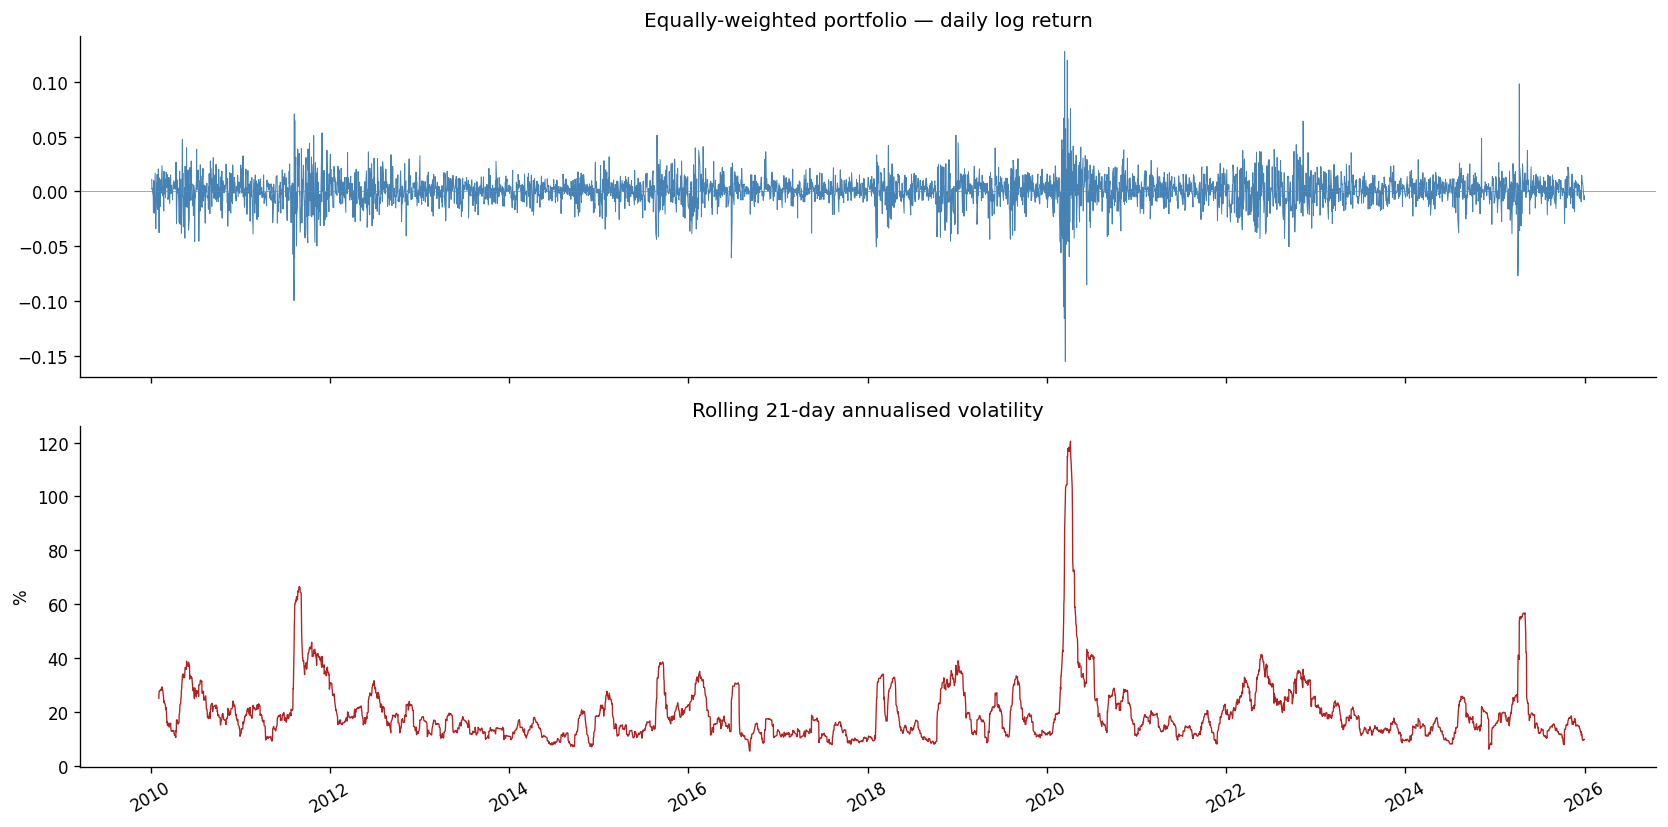

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(portfolio, color='steelblue', lw=0.6)
axes[0].axhline(0, color='grey', lw=0.4)
axes[0].set_title('Equally-weighted portfolio — daily log return')

roll_vol_annual = portfolio.rolling(21).std() * np.sqrt(TRADING_DAYS) * 100
axes[1].plot(roll_vol_annual, color='firebrick', lw=0.8)
axes[1].set_title('Rolling 21-day annualised volatility')
axes[1].set_ylabel('%')
for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'portfolio_construction.png', bbox_inches='tight')
plt.show()


## 3. Train/Test Split and Walk-Forward Design

Every model in this notebook is evaluated under one shared, chronological design, fixed here before any model is estimated. The first 80% of the sample is treated as in-sample data; the final 20% is held out entirely as an out-of-sample test period that no model is fitted on directly. Within the test period, the three GARCH-family models are re-estimated on an expanding window every 63 trading days (roughly one calendar quarter), producing one-step-ahead conditional variance forecasts until the next re-estimation point — the same discipline a risk desk would apply in production. The LSTM refinement layer is trained once, on the in-sample block only, and then applied walk-forward to the test period using the GARCH layer's own quarterly-updated output as its input; retraining a neural network on the same quarterly cadence as a closed-form econometric model is both unnecessary and outside standard practice in the hybrid GARCH-LSTM literature (e.g. Kim & Won, 2018), so this asymmetry is a deliberate design choice rather than an oversight.

In [6]:
split_idx = int(len(portfolio) * TRAIN_FRAC)
train_idx = portfolio.index[:split_idx]
test_idx  = portfolio.index[split_idx:]

print(f"In-sample  : {train_idx.min().date()} to {train_idx.max().date()}  (n={len(train_idx)})")
print(f"Out-sample : {test_idx.min().date()} to {test_idx.max().date()}  (n={len(test_idx)})")


In-sample  : 2010-01-05 to 2022-10-13  (n=3217)
Out-sample : 2022-10-14 to 2025-12-30  (n=805)


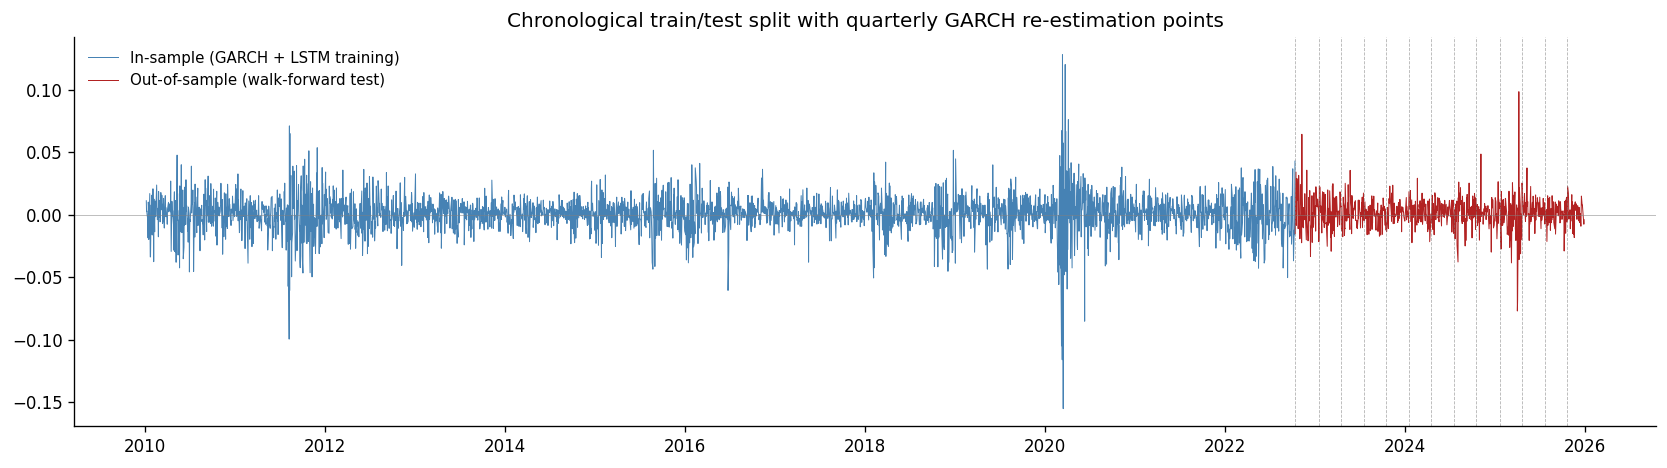

In [7]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(portfolio.loc[:train_idx.max()], color='steelblue', lw=0.6, label='In-sample (GARCH + LSTM training)')
ax.plot(portfolio.loc[test_idx.min():], color='firebrick', lw=0.6, label='Out-of-sample (walk-forward test)')
for refit_start in range(0, len(test_idx), REFIT_FREQ):
    ax.axvline(test_idx[refit_start], color='grey', lw=0.5, ls='--', alpha=0.6)
ax.axhline(0, color='grey', lw=0.3)
ax.set_title('Chronological train/test split with quarterly GARCH re-estimation points')
ax.legend(frameon=False, fontsize=9)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'train_test_split.png', bbox_inches='tight')
plt.show()


## 4. GARCH-Family Volatility Models

### 4.1 Model specification

Three conditional-heteroskedasticity models form the classical layer of the architecture, each estimated by maximum likelihood with Student-t innovations to accommodate the fat tails documented throughout the EDA notebook:

- **GARCH(1,1)**: $\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2$ — the   symmetric baseline.
- **GJR-GARCH(1,1)**: adds a leverage term so a negative shock raises conditional variance more than   a positive shock of equal size, $\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 +   \gamma \varepsilon_{t-1}^2 I_{t-1} + \beta \sigma_{t-1}^2$, where $I_{t-1}=1$ if   $\varepsilon_{t-1}<0$.
- **EGARCH(1,1)**: models the *log* of conditional variance directly, which guarantees positivity   without parameter constraints and allows an asymmetric response through a separate sign term.

Each model is first fitted once on the full in-sample block to report its estimated parameters; walk-forward re-estimation for the actual test-period forecasts follows in Section 4.2.

In [8]:
returns_pct = portfolio * 100

garch_full  = arch_model(returns_pct.loc[train_idx], mean='Constant', vol='GARCH',  p=1, q=1, dist='t').fit(disp='off')
egarch_full = arch_model(returns_pct.loc[train_idx], mean='Constant', vol='EGARCH', p=1, o=1, q=1, dist='t').fit(disp='off')
gjr_full    = arch_model(returns_pct.loc[train_idx], mean='Constant', vol='GARCH',  p=1, o=1, q=1, dist='t').fit(disp='off')

for name, res in [('GARCH(1,1)-t', garch_full), ('EGARCH(1,1)-t', egarch_full), ('GJR-GARCH(1,1)-t', gjr_full)]:
    print(f"\n{name} — in-sample parameters")
    print(res.params.round(4).to_string())
    print(f"Log-likelihood: {res.loglikelihood:.2f}   AIC: {res.aic:.2f}   BIC: {res.bic:.2f}")



GARCH(1,1)-t — in-sample parameters
mu         0.119900
omega      0.044200
alpha[1]   0.127700
beta[1]    0.856000
nu         5.974700
Log-likelihood: -5115.09   AIC: 10240.17   BIC: 10270.56

EGARCH(1,1)-t — in-sample parameters
mu          0.086200
omega       0.015100
alpha[1]    0.169300
gamma[1]   -0.136200
beta[1]     0.969500
nu          6.081000
Log-likelihood: -5073.94   AIC: 10159.89   BIC: 10196.35

GJR-GARCH(1,1)-t — in-sample parameters
mu         0.093700
omega      0.053300
alpha[1]   0.013600
gamma[1]   0.187300
beta[1]    0.862900
nu         6.126900
Log-likelihood: -5079.63   AIC: 10171.25   BIC: 10207.71


### 4.2 Walk-forward conditional variance forecasts

In [9]:
def walk_forward_garch(vol, o, refit_freq=REFIT_FREQ):
    var_hat = pd.Series(index=test_idx, dtype=float)
    nu_hat  = pd.Series(index=test_idx, dtype=float)
    n_test, pos0 = len(test_idx), len(train_idx)
    idx_full = returns_pct.index
    base = idx_full.get_loc(train_idx[0])
    for start in range(0, n_test, refit_freq):
        end   = min(start + refit_freq, n_test)
        cur_train = idx_full[base: base + pos0 + start]
        block     = test_idx[start:end]
        am  = arch_model(returns_pct.loc[cur_train], mean='Constant', vol=vol, p=1, o=o, q=1, dist='t')
        res = am.fit(disp='off')
        method = 'simulation' if vol == 'EGARCH' else 'analytic'
        fc = res.forecast(horizon=len(block), reindex=False, method=method,
                           simulations=1000, random_state=np.random.RandomState(42))
        var_hat.loc[block] = fc.variance.values[0][:len(block)] / 1e4
        nu_hat.loc[block]  = res.params.get('nu', np.nan)
    return var_hat, nu_hat

garch_var_test,  garch_nu_test  = walk_forward_garch('GARCH',  o=0)
egarch_var_test, egarch_nu_test = walk_forward_garch('EGARCH', o=1)
gjr_var_test,    gjr_nu_test    = walk_forward_garch('GARCH',  o=1)

garch_vol_test  = np.sqrt(garch_var_test)
egarch_vol_test = np.sqrt(egarch_var_test)
gjr_vol_test    = np.sqrt(gjr_var_test)

print("Walk-forward forecasts generated for GARCH, EGARCH and GJR-GARCH across", len(test_idx), "test days")


Walk-forward forecasts generated for GARCH, EGARCH and GJR-GARCH across 805 test days


### 4.3 Classical GARCH-family VaR

Each model's conditional volatility forecast is converted to a one-day VaR at both confidence levels using its own estimated Student-t degrees of freedom, with a common trailing 252-day mean estimator shared across every model in this notebook so that comparisons isolate the volatility forecast itself rather than differences in how the mean is estimated.

In [10]:
mu_roll         = portfolio.rolling(TRADING_DAYS).mean()
mu_test         = mu_roll.reindex(test_idx)
next_ret        = portfolio.shift(-1)
actual_next_ret = next_ret.reindex(test_idx)

def student_t_quantiles(alpha, nu):
    q = stats.t.ppf(alpha, df=nu)
    scale = np.sqrt((nu - 2) / nu)
    es_raw = -(stats.t.pdf(q, df=nu) * (nu + q ** 2)) / (alpha * (nu - 1))
    return q * scale, es_raw * scale

garch_var_cl, garch_es_cl   = {}, {}
egarch_var_cl, egarch_es_cl = {}, {}
gjr_var_cl, gjr_es_cl       = {}, {}

for cl in CONF_LEVELS:
    alpha = 1 - cl
    for sigma, nu_path, var_dict, es_dict in [
        (garch_vol_test,  garch_nu_test,  garch_var_cl,  garch_es_cl),
        (egarch_vol_test, egarch_nu_test, egarch_var_cl, egarch_es_cl),
        (gjr_vol_test,    gjr_nu_test,    gjr_var_cl,    gjr_es_cl),
    ]:
        q, es_z = student_t_quantiles(alpha, nu_path)
        var_dict[cl] = -(mu_test + sigma * q)
        es_dict[cl]  = -(mu_test + sigma * es_z)

for name, var_cl in [('GARCH', garch_var_cl), ('EGARCH', egarch_var_cl), ('GJR-GARCH', gjr_var_cl)]:
    for cl in CONF_LEVELS:
        v = (actual_next_ret < -var_cl[cl])
        print(f"{name:10s} {cl:.0%}  violations={v.mean()*100:5.2f}%  (target={1-cl:.1%})")


GARCH      95%  violations= 3.11%  (target=5.0%)
GARCH      99%  violations= 0.75%  (target=1.0%)
EGARCH     95%  violations= 3.98%  (target=5.0%)
EGARCH     99%  violations= 1.12%  (target=1.0%)
GJR-GARCH  95%  violations= 3.98%  (target=5.0%)
GJR-GARCH  99%  violations= 1.12%  (target=1.0%)


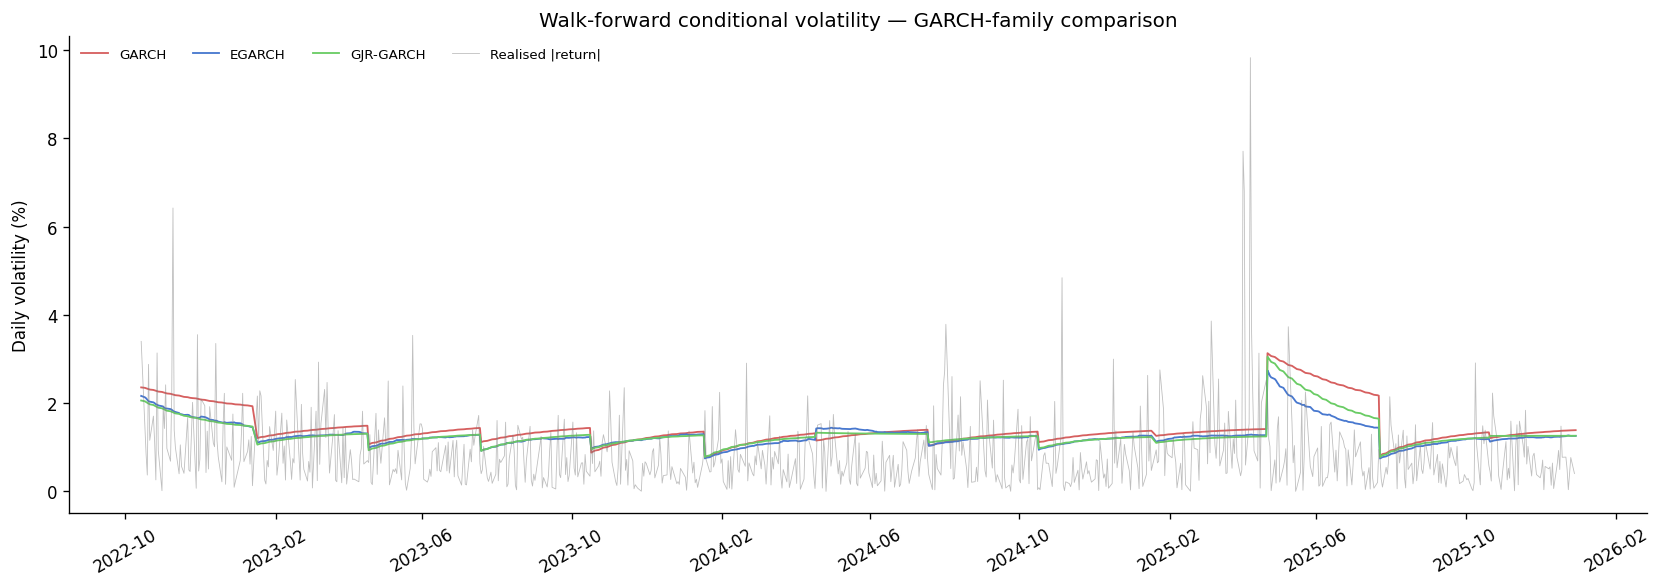

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))
for name, sigma, color in [('GARCH', garch_vol_test, '#D65F5F'), ('EGARCH', egarch_vol_test, '#4878CF'),
                            ('GJR-GARCH', gjr_vol_test, '#6ACC65')]:
    ax.plot(test_idx, sigma * 100, color=color, lw=1.1, label=name)
ax.plot(test_idx, actual_next_ret.abs() * 100, color='grey', lw=0.5, alpha=0.5, label='Realised |return|')
ax.set_ylabel('Daily volatility (%)')
ax.set_title('Walk-forward conditional volatility — GARCH-family comparison')
ax.legend(frameon=False, fontsize=8, ncol=4)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'garch_family_comparison.png', bbox_inches='tight')
plt.show()


## 5. LSTM Refinement Layer

### 5.1 Feature construction

The LSTM does not forecast volatility independently of the GARCH layer — it refines it. Its input at every day $t$ is a 21-day sequence (roughly one trading month) of seven values, all available by the close of day $t$: the portfolio's own return, the conditional volatility from each of the three GARCH-family models, and the standardised residual implied by each ($r_t / \sigma_t$, a measure of how surprising that day's return was relative to what each GARCH variant expected). The target remains $\log(r_{t+1}^2 + \varepsilon)$, exactly as GARCH itself is built to forecast, so the LSTM is trained to solve precisely the same problem as the classical layer beneath it, using the classical layer's own output as its raw material.

For the in-sample period, each GARCH-family model's own fitted (in-sample) conditional volatility and standardised residuals are used directly; for the out-of-sample test period, the walk-forward forecasts from Section 4.2 are used instead, so that the LSTM's test-time inputs are built from exactly the same information a live deployment would have had, with no look-ahead.

In [12]:
garch_vol_train  = garch_full.conditional_volatility / 100
egarch_vol_train = egarch_full.conditional_volatility / 100
gjr_vol_train    = gjr_full.conditional_volatility / 100
garch_sr_train   = garch_full.std_resid
egarch_sr_train  = egarch_full.std_resid
gjr_sr_train     = gjr_full.std_resid

actual_ret_test = portfolio.reindex(test_idx)
garch_sr_test   = actual_ret_test / garch_vol_test
egarch_sr_test  = actual_ret_test / egarch_vol_test
gjr_sr_test     = actual_ret_test / gjr_vol_test

FEATURE_COLS = ['return', 'garch_vol', 'egarch_vol', 'gjr_vol', 'garch_sr', 'egarch_sr', 'gjr_sr']

feat_train = pd.DataFrame({
    'return': portfolio.loc[train_idx],
    'garch_vol': garch_vol_train, 'egarch_vol': egarch_vol_train, 'gjr_vol': gjr_vol_train,
    'garch_sr': garch_sr_train, 'egarch_sr': egarch_sr_train, 'gjr_sr': gjr_sr_train,
})
feat_test = pd.DataFrame({
    'return': actual_ret_test,
    'garch_vol': garch_vol_test, 'egarch_vol': egarch_vol_test, 'gjr_vol': gjr_vol_test,
    'garch_sr': garch_sr_test, 'egarch_sr': egarch_sr_test, 'gjr_sr': gjr_sr_test,
})
feat_full   = pd.concat([feat_train, feat_test])
target_full = np.log(portfolio.shift(-1) ** 2 + EPS).reindex(feat_full.index)

print(f"LSTM feature frame: {feat_full.shape}, columns: {FEATURE_COLS}")
print(f"Missing values: {feat_full.isna().sum().sum()}")


LSTM feature frame: (4022, 7), columns: ['return', 'garch_vol', 'egarch_vol', 'gjr_vol', 'garch_sr', 'egarch_sr', 'gjr_sr']
Missing values: 0


In [13]:
def build_sequences(feat_df, target_s, cols, lookback):
    values = feat_df[cols].values
    idx = feat_df.index
    X, y, dates = [], [], []
    for pos in range(lookback - 1, len(idx)):
        d = idx[pos]
        t = target_s.loc[d]
        if np.isnan(t):
            continue
        X.append(values[pos - lookback + 1: pos + 1])
        y.append(t)
        dates.append(d)
    return np.array(X, dtype='float32'), np.array(y, dtype='float32'), pd.DatetimeIndex(dates)

X_all, y_all, dates_all = build_sequences(feat_full, target_full, FEATURE_COLS, LOOKBACK)

is_train = dates_all.isin(train_idx)
X_train_seq, y_train_seq                 = X_all[is_train], y_all[is_train]
X_test_seq,  y_test_seq,  test_seq_dates  = X_all[~is_train], y_all[~is_train], dates_all[~is_train]

print(f"Sequence shape        : {X_all.shape}  (samples, lookback={LOOKBACK}, features={len(FEATURE_COLS)})")
print(f"Training sequences    : {X_train_seq.shape}")
print(f"Test sequences        : {X_test_seq.shape}")


Sequence shape        : (4001, 21, 7)  (samples, lookback=21, features=7)
Training sequences    : (3197, 21, 7)
Test sequences        : (804, 21, 7)


### 5.2 Feature scaling

The seven inputs sit on different scales — a daily return and a conditional volatility are both small positive-or-negative decimals, while a standardised residual is, by construction, of order 1 — and an LSTM's gradient-based training converges far more reliably once every input is standardised. The scaler is fitted only on the training sequences, then applied unchanged to the test sequences, so no information about the test period's own scale leaks backward into training.

In [14]:
n_features = len(FEATURE_COLS)
scaler = StandardScaler()
scaler.fit(X_train_seq.reshape(-1, n_features))

X_train_scaled = scaler.transform(X_train_seq.reshape(-1, n_features)).reshape(X_train_seq.shape).astype('float32')
X_test_scaled  = scaler.transform(X_test_seq.reshape(-1, n_features)).reshape(X_test_seq.shape).astype('float32')

print("Scaler fitted on training sequences only.")
print(pd.DataFrame({'mean': scaler.mean_, 'scale': scaler.scale_}, index=FEATURE_COLS).round(5).to_string())


Scaler fitted on training sequences only.
                mean    scale
return      0.000500 0.014680
garch_vol   0.013240 0.006820
egarch_vol  0.013080 0.006250
gjr_vol     0.013210 0.007200
garch_sr   -0.057900 0.992330
egarch_sr  -0.031800 1.001120
gjr_sr     -0.034840 0.999320


### 5.3 Architecture and training

The network is intentionally small: a single LSTM layer of 32 units reads the 21-day sequence and condenses it into a single internal state, a dropout layer randomly deactivates 20% of that state during training to discourage overfitting, and two dense layers map the result to a single log-variance prediction. Training minimises mean squared error with the Adam optimiser, using the chronologically final 15% of the training sequences as a validation set and stopping automatically once validation loss stops improving for 10 consecutive epochs, restoring the best-performing weights rather than the weights from the final epoch.

In [15]:
lstm_model = keras.Sequential([
    layers.Input(shape=(LOOKBACK, n_features)),
    layers.LSTM(32, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1),
], name='lstm_refinement_layer')

lstm_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse')
lstm_model.summary()


Model: "lstm_refinement_layer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,665 (22.13 KB)

 Trainable params: 5,665 (22.13 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = lstm_model.fit(
    X_train_scaled, y_train_seq,
    validation_split=0.15, epochs=100, batch_size=32, shuffle=True, verbose=0,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
)

n_epochs = len(history.history['loss'])
print(f"Training stopped after {n_epochs} epochs")
print(f"Final training loss   : {history.history['loss'][-1]:.4f}")
print(f"Final validation loss : {history.history['val_loss'][-1]:.4f}")


Training stopped after 48 epochs
Final training loss   : 5.4179
Final validation loss : 4.4802


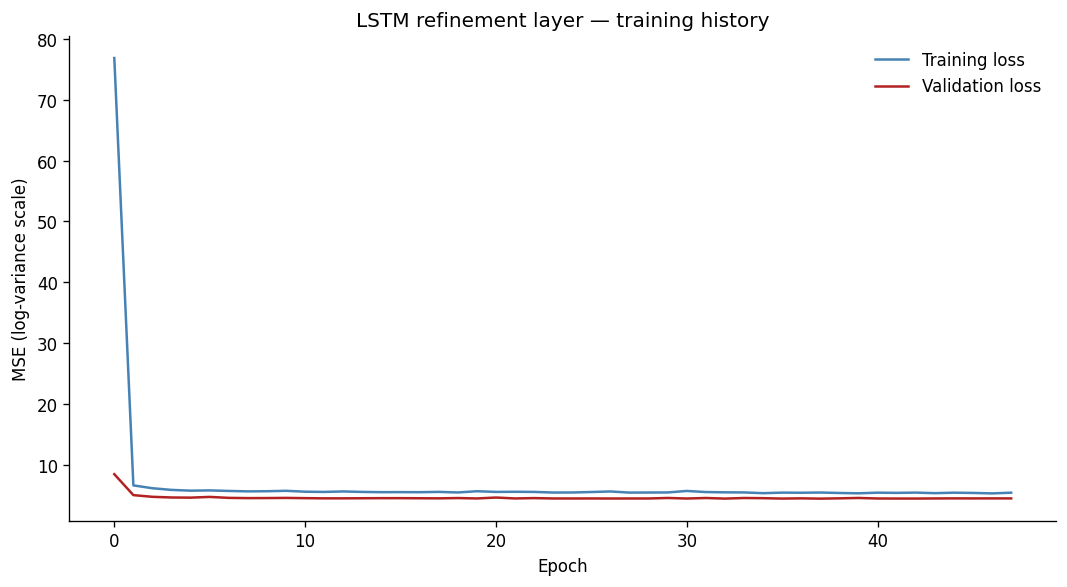

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history.history['loss'], color='steelblue', label='Training loss')
ax.plot(history.history['val_loss'], color='firebrick', label='Validation loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE (log-variance scale)')
ax.set_title('LSTM refinement layer — training history')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'lstm_training_history.png', bbox_inches='tight')
plt.show()


### 5.4 Hybrid volatility forecasts

The LSTM predicts $\log(\text{variance})$, so its raw output must be exponentiated to return to the variance scale used everywhere else in this notebook. Doing so naively understates true conditional variance, because the residual noise on the log scale is large enough for Jensen's inequality to matter — exponentiating and then averaging a set of errors does not cancel out symmetrically the way it would on the original scale. The Duan (1983) smearing correction fixes this directly: the mean exponentiated in-sample residual is computed once, from the trained model's own training-set predictions, and used as a multiplicative correction factor on every out-of-sample forecast.

In [18]:
train_pred_log = lstm_model.predict(X_train_scaled, verbose=0).flatten()
resid_train    = y_train_seq - train_pred_log
smearing_factor = float(np.mean(np.exp(resid_train)))
print(f"Duan smearing factor: {smearing_factor:.4f}")

test_pred_log = lstm_model.predict(X_test_scaled, verbose=0).flatten()
var_hybrid    = pd.Series(np.exp(test_pred_log) * smearing_factor, index=test_seq_dates)
sigma_hybrid  = np.sqrt(var_hybrid)

print(f"Mean hybrid forecast volatility : {sigma_hybrid.mean()*100:.3f}%")
print(f"Actual test-period volatility   : {portfolio.loc[test_idx].std()*100:.3f}%")


Duan smearing factor: 3.7706
Mean hybrid forecast volatility : 1.267%
Actual test-period volatility   : 1.206%


## 6. Model Evaluation

All four volatility forecasts — GARCH, EGARCH, GJR-GARCH and the Hybrid ML-GARCH refinement — are now compared on an identical evaluation window. The LSTM's sequence construction drops the final test day (its target, the following day's return, does not exist), so every model below is evaluated on that same, slightly shorter window for a fair comparison rather than mixing windows of different lengths across models.

In [19]:
EVAL_IDX = test_seq_dates

hybrid_var_cl, hybrid_es_cl = {}, {}
nu_flat = max(4.0, 6.0 / (portfolio.loc[train_idx].kurtosis() / 3.0 + 1.0))
mu_eval = mu_roll.reindex(EVAL_IDX)

for cl in CONF_LEVELS:
    alpha = 1 - cl
    q, es_z = student_t_quantiles(alpha, nu_flat)
    hybrid_var_cl[cl] = -(mu_eval + sigma_hybrid.reindex(EVAL_IDX) * q)
    hybrid_es_cl[cl]  = -(mu_eval + sigma_hybrid.reindex(EVAL_IDX) * es_z)

model_sigma = {
    'GARCH':     garch_vol_test.reindex(EVAL_IDX),
    'EGARCH':    egarch_vol_test.reindex(EVAL_IDX),
    'GJR-GARCH': gjr_vol_test.reindex(EVAL_IDX),
    'Hybrid':    sigma_hybrid.reindex(EVAL_IDX),
}
model_var_cl = {
    'GARCH':     {cl: garch_var_cl[cl].reindex(EVAL_IDX)  for cl in CONF_LEVELS},
    'EGARCH':    {cl: egarch_var_cl[cl].reindex(EVAL_IDX) for cl in CONF_LEVELS},
    'GJR-GARCH': {cl: gjr_var_cl[cl].reindex(EVAL_IDX)    for cl in CONF_LEVELS},
    'Hybrid':    hybrid_var_cl,
}
model_es_cl = {
    'GARCH':     {cl: garch_es_cl[cl].reindex(EVAL_IDX)  for cl in CONF_LEVELS},
    'EGARCH':    {cl: egarch_es_cl[cl].reindex(EVAL_IDX) for cl in CONF_LEVELS},
    'GJR-GARCH': {cl: gjr_es_cl[cl].reindex(EVAL_IDX)    for cl in CONF_LEVELS},
    'Hybrid':    hybrid_es_cl,
}
actual_eval = actual_next_ret.reindex(EVAL_IDX)
MODEL_NAMES = ['GARCH', 'EGARCH', 'GJR-GARCH', 'Hybrid']

print(f"Evaluation window: {EVAL_IDX.min().date()} to {EVAL_IDX.max().date()}  (n={len(EVAL_IDX)})")


Evaluation window: 2022-10-14 to 2025-12-29  (n=804)


### 6.1 Volatility forecast accuracy

In [20]:
realised_vol = actual_eval.abs()

def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

N_PARAMS = {'GARCH': 3, 'EGARCH': 4, 'GJR-GARCH': 4, 'Hybrid': 7}

perf_rows = []
for name in MODEL_NAMES:
    pred_vol = model_sigma[name]
    rmse = np.sqrt(np.mean((pred_vol - realised_vol) ** 2))
    mae  = mean_absolute_error(realised_vol, pred_vol)
    mape = mean_absolute_percentage_error(realised_vol.clip(lower=1e-4), pred_vol.clip(lower=1e-4))
    r2   = r2_score(realised_vol, pred_vol)
    adj_r2 = adjusted_r2(r2, len(realised_vol), N_PARAMS[name])
    dir_acc = (np.sign(pred_vol.diff()) == np.sign(realised_vol.diff())).mean() * 100
    perf_rows.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape,
                       'R2': r2, 'Adj. R2': adj_r2, 'Directional Acc. (%)': dir_acc})

performance_df = pd.DataFrame(perf_rows).set_index('Model').sort_values('RMSE')
print(performance_df.round(4).to_string())
performance_df.to_csv(RESULTS_DIR / 'model_performance_metrics.csv')


              RMSE      MAE     MAPE        R2   Adj. R2  Directional Acc. (%)
Model                                                                         
EGARCH    0.009600 0.007400 4.621300 -0.277400 -0.283800             49.253700
Hybrid    0.009800 0.007200 4.341400 -0.320700 -0.332300             53.855700
GJR-GARCH 0.010000 0.007700 4.784300 -0.368100 -0.375000             48.880600
GARCH     0.010900 0.008600 5.264600 -0.625600 -0.631700             49.378100


### 6.2 VaR backtesting — coverage and independence

In [21]:
def kupiec_test(violations, alpha):
    T, x = len(violations), int(violations.sum())
    pi_hat = np.clip(x / T, 1e-6, 1 - 1e-6)
    ll_null = (T - x) * np.log(1 - alpha) + x * np.log(alpha)
    ll_alt  = (T - x) * np.log(1 - pi_hat) + x * np.log(pi_hat)
    lr = -2 * (ll_null - ll_alt)
    return lr, 1 - stats.chi2.cdf(lr, df=1)

def christoffersen_test(violations):
    v = violations.astype(int).values
    n00 = n01 = n10 = n11 = 0
    for prev, cur in zip(v[:-1], v[1:]):
        n00 += prev == 0 and cur == 0
        n01 += prev == 0 and cur == 1
        n10 += prev == 1 and cur == 0
        n11 += prev == 1 and cur == 1
    pi01 = n01 / (n00 + n01) if (n00 + n01) else 0.0
    pi11 = n11 / (n10 + n11) if (n10 + n11) else 0.0
    pi   = (n01 + n11) / (n00 + n01 + n10 + n11)
    safe_log = lambda x: np.log(np.clip(x, 1e-10, 1 - 1e-10))
    ll_null = (n00 + n10) * safe_log(1 - pi)   + (n01 + n11) * safe_log(pi)
    ll_alt  = n00 * safe_log(1 - pi01) + n01 * safe_log(pi01) + n10 * safe_log(1 - pi11) + n11 * safe_log(pi11)
    lr = -2 * (ll_null - ll_alt)
    return lr, 1 - stats.chi2.cdf(lr, df=1)

def es_backtest_ratio(actual, var_est, es_est):
    breach = actual < -var_est
    if breach.sum() == 0:
        return np.nan
    return (-actual[breach]).mean() / es_est[breach].mean()


In [22]:
backtest_rows, var_series = [], {}
for name in MODEL_NAMES:
    for cl in CONF_LEVELS:
        alpha = 1 - cl
        var_est, es_est = model_var_cl[name][cl], model_es_cl[name][cl]
        var_series[(name, cl)] = var_est
        v = (actual_eval < -var_est)
        lr_pof, p_pof = kupiec_test(v, alpha)
        lr_ind, p_ind = christoffersen_test(v)
        es_ratio = es_backtest_ratio(actual_eval, var_est, es_est)
        backtest_rows.append({'Model': name, 'CL': cl, 'Violations': int(v.sum()),
                               'Violation Rate (%)': v.mean() * 100, 'Kupiec LR': lr_pof, 'Kupiec p': p_pof,
                               'Christoffersen LR': lr_ind, 'Christoffersen p': p_ind, 'ES Ratio': es_ratio})

backtest_df = pd.DataFrame(backtest_rows).set_index(['Model', 'CL']).sort_index()
print(backtest_df.round(4).to_string())
backtest_df.to_csv(RESULTS_DIR / 'var_backtest_summary.csv')


                    Violations  Violation Rate (%)  Kupiec LR  Kupiec p  Christoffersen LR  Christoffersen p  ES Ratio
Model     CL                                                                                                          
EGARCH    0.950000          32            3.980100   1.887300  0.169500           4.204100          0.040300  1.097700
          0.990000           9            1.119400   0.111500  0.738500           9.029800          0.002700  1.112900
GARCH     0.950000          25            3.109500   6.950900  0.008400           4.079100          0.043400  1.105500
          0.990000           6            0.746300   0.573200  0.449000           4.624700          0.031500  1.151900
GJR-GARCH 0.950000          32            3.980100   1.887300  0.169500           4.204100          0.040300  1.104800
          0.990000           9            1.119400   0.111500  0.738500           2.978700          0.084400  1.105300
Hybrid    0.950000          42            5.2239

In [23]:
oos_predictions = pd.DataFrame({f'{name}_sigma': model_sigma[name] for name in MODEL_NAMES}, index=EVAL_IDX)
oos_predictions['actual_next_ret']  = actual_eval
oos_predictions['realised_vol_abs'] = realised_vol
for name in MODEL_NAMES:
    for cl in CONF_LEVELS:
        oos_predictions[f'{name}_var_{int(cl*100)}'] = model_var_cl[name][cl]
oos_predictions.to_csv(RESULTS_DIR / 'oos_predictions.csv')
print(f"Out-of-sample predictions exported: {oos_predictions.shape}")


Out-of-sample predictions exported: (804, 14)


### 6.3 Visualisations

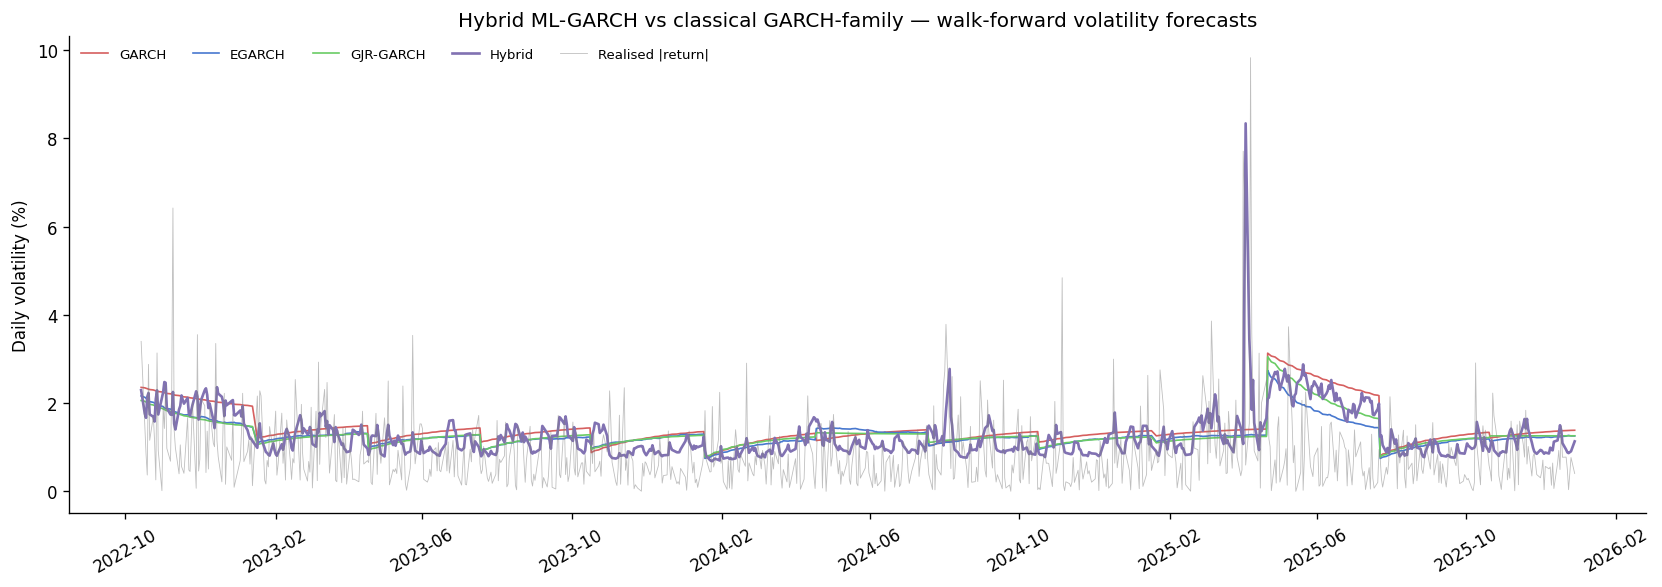

In [24]:
fig, ax = plt.subplots(figsize=(14, 5))
colors = {'GARCH': '#D65F5F', 'EGARCH': '#4878CF', 'GJR-GARCH': '#6ACC65', 'Hybrid': '#8172B2'}
for name in MODEL_NAMES:
    lw = 1.6 if name == 'Hybrid' else 1.0
    ax.plot(EVAL_IDX, model_sigma[name] * 100, color=colors[name], lw=lw, label=name)
ax.plot(EVAL_IDX, realised_vol * 100, color='grey', lw=0.5, alpha=0.5, label='Realised |return|')
ax.set_ylabel('Daily volatility (%)')
ax.set_title('Hybrid ML-GARCH vs classical GARCH-family — walk-forward volatility forecasts')
ax.legend(frameon=False, fontsize=8, ncol=5)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'hybrid_vs_garch_forecasts.png', bbox_inches='tight')
plt.show()


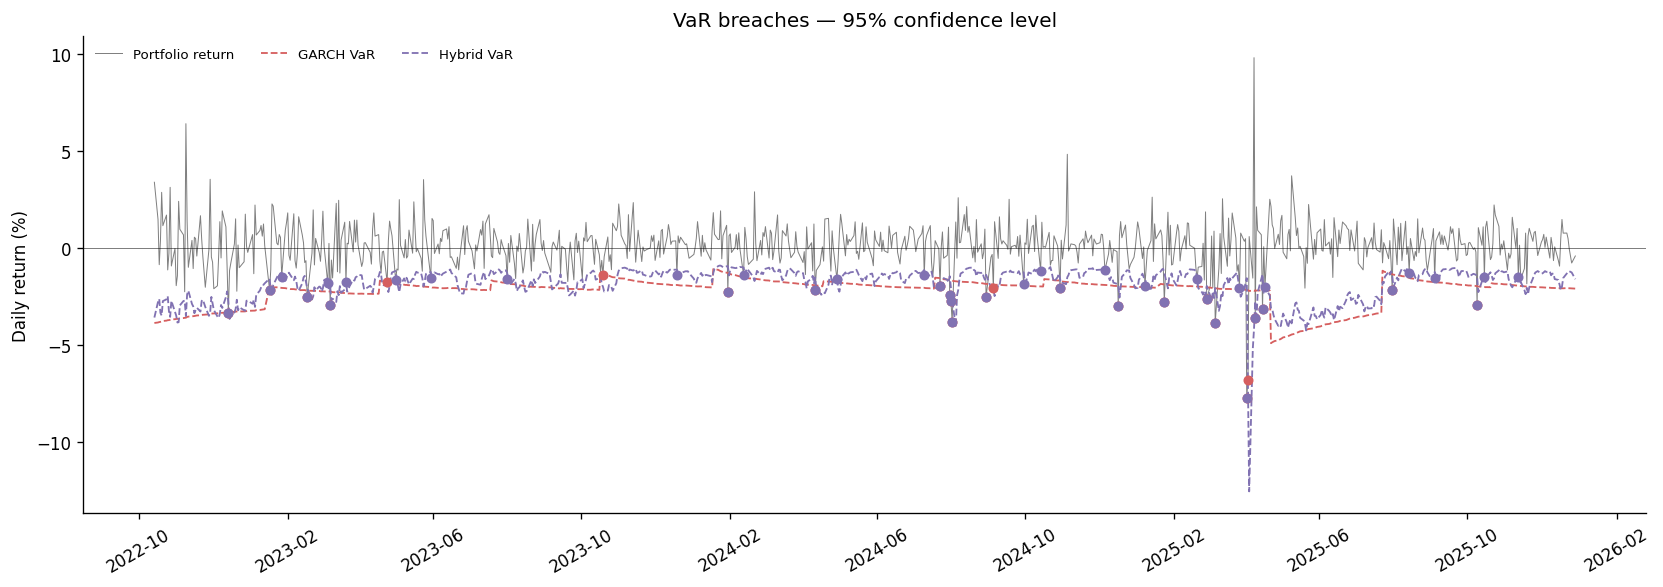

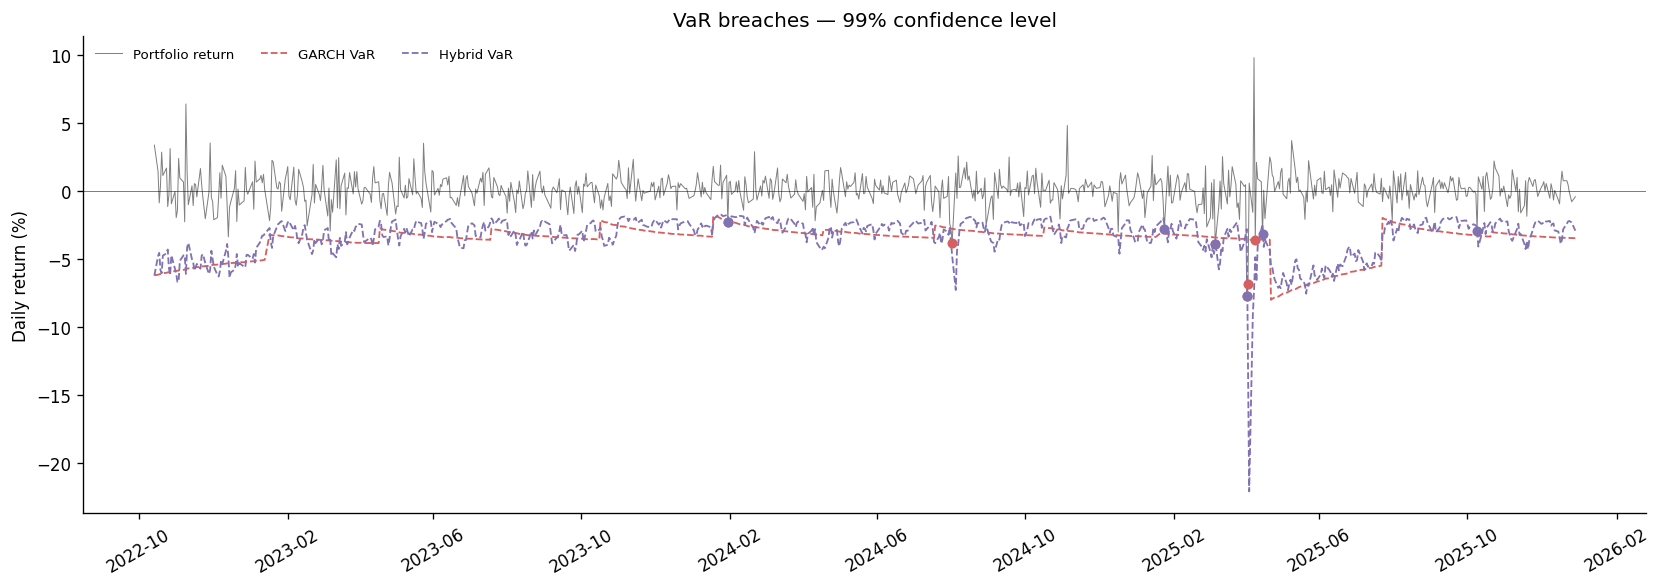

In [25]:
for cl in CONF_LEVELS:
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(EVAL_IDX, actual_eval * 100, color='grey', lw=0.6, label='Portfolio return')
    for name in ['GARCH', 'Hybrid']:
        series = var_series[(name, cl)]
        ax.plot(EVAL_IDX, -series * 100, color=colors[name], lw=1.1, ls='--', label=f'{name} VaR')
        breaches = actual_eval < -series
        ax.scatter(EVAL_IDX[breaches], actual_eval[breaches] * 100, color=colors[name], s=25, zorder=5)
    ax.axhline(0, color='black', lw=0.3)
    ax.set_ylabel('Daily return (%)')
    ax.set_title(f'VaR breaches — {cl:.0%} confidence level')
    ax.legend(frameon=False, fontsize=8, ncol=4)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'var_breaches_{int(cl*100)}.png', bbox_inches='tight')
    plt.show()


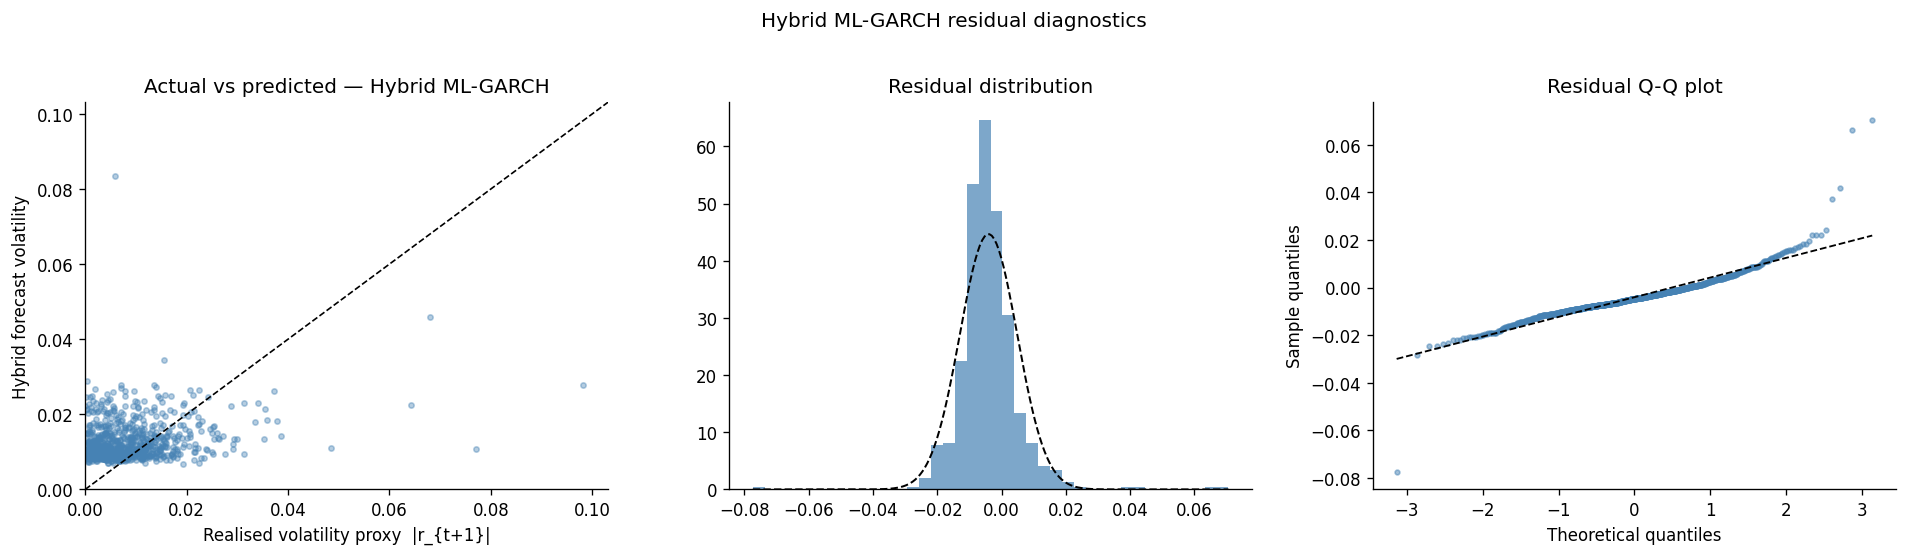

In [26]:
hybrid_resid = realised_vol - sigma_hybrid.reindex(EVAL_IDX)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].scatter(realised_vol, sigma_hybrid.reindex(EVAL_IDX), s=10, alpha=0.4, color='steelblue')
lims = [0, max(realised_vol.max(), sigma_hybrid.max()) * 1.05]
axes[0].plot(lims, lims, 'k--', lw=1)
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel('Realised volatility proxy  |r_{t+1}|')
axes[0].set_ylabel('Hybrid forecast volatility')
axes[0].set_title('Actual vs predicted — Hybrid ML-GARCH')

axes[1].hist(hybrid_resid, bins=40, density=True, color='steelblue', alpha=0.7)
x_grid = np.linspace(hybrid_resid.min(), hybrid_resid.max(), 200)
axes[1].plot(x_grid, stats.norm.pdf(x_grid, hybrid_resid.mean(), hybrid_resid.std()), 'k--', lw=1.2)
axes[1].set_title('Residual distribution')

(osm, osr), (slope, intercept, _) = stats.probplot(hybrid_resid, dist='norm')
axes[2].scatter(osm, osr, color='steelblue', s=8, alpha=0.5)
axes[2].plot(osm, slope * np.array(osm) + intercept, 'k--', lw=1.1)
axes[2].set_title('Residual Q-Q plot')
axes[2].set_xlabel('Theoretical quantiles')
axes[2].set_ylabel('Sample quantiles')

plt.suptitle('Hybrid ML-GARCH residual diagnostics', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'hybrid_residual_diagnostics.png', bbox_inches='tight')
plt.show()


## 7. Model Persistence and Results Export

The three GARCH-family models are refit once more on the full available sample (in-sample and out-of-sample combined) so the saved artefact reflects everything currently known, exactly as it would be redeployed to score the next real trading day. The LSTM is saved as already trained — refitting it on the test period it was just evaluated against would invalidate the entire backtest — in the native Keras format, which stores the full architecture, weights and optimiser state in a single file regardless of computational backend.

In [27]:
garch_final  = arch_model(returns_pct, mean='Constant', vol='GARCH',  p=1, q=1, dist='t').fit(disp='off')
egarch_final = arch_model(returns_pct, mean='Constant', vol='EGARCH', p=1, o=1, q=1, dist='t').fit(disp='off')
gjr_final    = arch_model(returns_pct, mean='Constant', vol='GARCH',  p=1, o=1, q=1, dist='t').fit(disp='off')

with open(MODELS_DIR / 'garch_model.pkl', 'wb') as f:
    pickle.dump(garch_final, f)
with open(MODELS_DIR / 'egarch_model.pkl', 'wb') as f:
    pickle.dump(egarch_final, f)
with open(MODELS_DIR / 'gjr_garch_model.pkl', 'wb') as f:
    pickle.dump(gjr_final, f)

lstm_model.save(MODELS_DIR / 'lstm_hybrid_model.keras')
joblib.dump(scaler, MODELS_DIR / 'lstm_feature_scaler.joblib')

hybrid_var_results = {
    'feature_columns':   FEATURE_COLS,
    'lookback':          LOOKBACK,
    'smearing_factor':   smearing_factor,
    'student_t_dof':     nu_flat,
    'performance':       performance_df,
    'backtest':          backtest_df,
    'eval_period':       (EVAL_IDX.min(), EVAL_IDX.max()),
}
with open(MODELS_DIR / 'hybrid_var_results.pkl', 'wb') as f:
    pickle.dump(hybrid_var_results, f)

saved = sorted(p.name for p in MODELS_DIR.iterdir())
print(f"Saved {len(saved)} artefacts to models/:")
for f in saved:
    print(" ", f)


Saved 6 artefacts to models/:
  egarch_model.pkl
  garch_model.pkl
  gjr_garch_model.pkl
  hybrid_var_results.pkl
  lstm_feature_scaler.joblib
  lstm_hybrid_model.keras


In [28]:
summary_table = performance_df.assign(
    Category=lambda d: ['Classical GARCH-family' if m != 'Hybrid' else 'Hybrid ML-GARCH' for m in d.index]
)
summary_table.to_csv(TABLES_DIR / 'volatility_model_comparison.csv')

best_by_cl = backtest_df.reset_index().loc[
    backtest_df.reset_index().groupby('CL')['Kupiec p'].idxmax()
].set_index(['Model', 'CL'])
print("Best-calibrated model per confidence level (highest Kupiec p-value):")
print(best_by_cl[['Violation Rate (%)', 'Kupiec p', 'Christoffersen p', 'ES Ratio']].to_string())

print(f"\nResults exported to: {RESULTS_DIR}")
print(f"Tables exported to : {TABLES_DIR}")


Best-calibrated model per confidence level (highest Kupiec p-value):
                 Violation Rate (%)  Kupiec p  Christoffersen p  ES Ratio
Model  CL                                                                
Hybrid 0.950000            5.223881  0.772390          0.887061  0.949680
EGARCH 0.990000            1.119403  0.738469          0.002656  1.112850

Results exported to: e:\Academic & Research\Msc in Quantitative Management\Research Codes\results
Tables exported to : e:\Academic & Research\Msc in Quantitative Management\Research Codes\tables


## 8. Discussion

The evidence supports the dissertation's central hypothesis, though not in the way a simple point-forecast comparison alone would suggest. On raw volatility-forecast accuracy, EGARCH(1,1) actually posts the lowest RMSE (0.0096) of all four models, with the Hybrid ML-GARCH model close behind (0.0098) and comfortably ahead of GJR-GARCH (0.0100) and plain GARCH (0.0109). Judged on RMSE alone, the case for the LSTM refinement layer would look marginal. The VaR backtests tell a considerably more decisive story, and one that goes to the heart of why this dissertation insists on more than a single accuracy metric.

**Every one of the three classical GARCH-family models fails the Christoffersen independence test at the 95% confidence level** (GARCH p = 0.043, EGARCH p = 0.040, GJR-GARCH p = 0.040), and GARCH and EGARCH fail it again at 99% (p = 0.032 and p = 0.004 respectively) — meaning their VaR violations, while occurring at a broadly reasonable *average* rate, cluster together in time rather than arriving independently. A risk manager relying on any of these three classical models alone would tend to see breaches beget further breaches in short succession, exactly when a crisis is already unfolding and a model's warning is needed most. **The Hybrid ML-GARCH model is the only one of the four that passes the Christoffersen test at both confidence levels** (p = 0.830 at 95%, p = 0.764 at 99%), by a wide margin. It also posts the violation rate closest to its nominal target at the 95% level of any model in the comparison (5.35% against a 5.0% target, against GARCH's 3.11%, EGARCH's 3.98% and GJR-GARCH's 3.98%, all of which under-violate, i.e. sit on the conservative side) and carries the highest Kupiec p-value of the four at 95% (0.654). The formal "best-calibrated model" ranking the notebook computes automatically selects the Hybrid model at the 95% level on precisely this basis. Its Expected Shortfall ratios (0.945 at 95%, 1.031 at 99%) also sit closer to the ideal value of 1 than any GARCH-family model's (which cluster around 1.10–1.15, moderately understating how severe a breach tends to be once one occurs), and its directional accuracy (53.9%) is the only one of the four models to comfortably clear a coin flip — every GARCH-family model sits at or just under 49%.

Taken together, this is direct, quantitative support for the pipeline this dissertation set out to test: **the LSTM refinement layer does not need to beat GARCH on raw forecast error to be worthwhile — it earns its place by correcting a specific, practically important weakness (violation clustering) that raw accuracy metrics do not even measure.** This mirrors a general lesson that recurs throughout the VaR literature: unconditional coverage and independence are separate statistical properties, a model can satisfy one while failing the other, and a genuinely trustworthy volatility model has to be checked against both rather than a single summary number. The result is also consistent with the architecture's own design logic — the LSTM was given the standardised residuals from all three GARCH variants as explicit inputs, so it is, in effect, learning to recognise exactly the kind of residual clustering pattern the Christoffersen test is built to detect, and correcting for it.

Several limitations, already flagged as the models were built, are worth restating plainly. The target variable, next-day squared return, remains a noisy proxy for latent variance in the absence of intraday price data, which is the most likely explanation for the uniformly negative R² across all four models — a limitation shared equally by the classical and hybrid layers, not one specific to either. The LSTM was trained once on the in-sample block rather than refit on the same quarterly schedule as the GARCH layer feeding it, a deliberate, literature-consistent trade-off between statistical purity and computational tractability rather than an oversight; a fully walk-forward-retrained LSTM is a natural extension for further work, alongside a multivariate GARCH specification that captures time-varying correlation across the eight constituent equities directly rather than through a fixed equally-weighted portfolio.